In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
import torch
import os
import sys

from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT

# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score

def seed_torch(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(seed=42)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

cuda


In [9]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Amazon Ratings", node_feature_type="amazon-mpnet-base-v2")

In [10]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

In [11]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
dataset = GAResearchDataset(root ='tmp/amazon-mpnet-base-v2', name='amazon-mpnet-base-v2')

In [12]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 768
Number of num_classes : 5
Number of num_nodes : 24492
Number of num_edges : 186100


In [13]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([24492, 10])
torch.Size([24492, 10])
torch.Size([24492, 10])


In [14]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([False,  True,  True,  ...,  True,  True,  True])
torch.Size([24492])


## Class Distribution

In [15]:
import numpy as np

labels = dataset.data.y

counts = np.bincount(labels)
print("Class Distribution for Amazon Ratings:")
for i, count in enumerate(counts):
    percentage = (count / len(labels)) * 100
    print(f"Rating {i}: {count:>6} samples ({percentage:5.2f}%)")


Class Distribution for Amazon Ratings:
Rating 0:   6560 samples (26.78%)
Rating 1:   9010 samples (36.79%)
Rating 2:   5678 samples (23.18%)
Rating 3:   2183 samples ( 8.91%)
Rating 4:   1061 samples ( 4.33%)


/tmp/ipykernel_312943/1619669783.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  labels = dataset.data.y


# Training Subroutine

In [16]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    acc = accuracy_score(y, pred)
    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [18]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    #test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(5), yticklabels=range(5))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    
    return model, train_losses, val_f1s, test_f1s, training_time

In [19]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [20]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [21]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 1.3815, Val F1: 0.2029,Val Acc: 0.3475, Time: 0.01s
Epoch: 020, Loss: 1.2744, Val F1: 0.1735,Val Acc: 0.3967, Time: 0.01s
Epoch: 030, Loss: 1.2291, Val F1: 0.2822,Val Acc: 0.4383, Time: 0.01s
Epoch: 040, Loss: 1.1794, Val F1: 0.2867,Val Acc: 0.4537, Time: 0.01s
Epoch: 050, Loss: 1.1357, Val F1: 0.2962,Val Acc: 0.4537, Time: 0.01s
Epoch: 060, Loss: 1.0863, Val F1: 0.3250,Val Acc: 0.4592, Time: 0.01s
Epoch: 070, Loss: 1.0411, Val F1: 0.3599,Val Acc: 0.4708, Time: 0.01s
Epoch: 080, Loss: 1.0018, Val F1: 0.3630,Val Acc: 0.4726, Time: 0.01s
Epoch: 090, Loss: 0.9718, Val F1: 0.3766,Val Acc: 0.4690, Time: 0.01s
Epoch: 100, Loss: 0.9410, Val F1: 0.3820,Val Acc: 0.4814, Time: 0.01s
Test F1: 0.3750
Test Accuracy: 0.4701


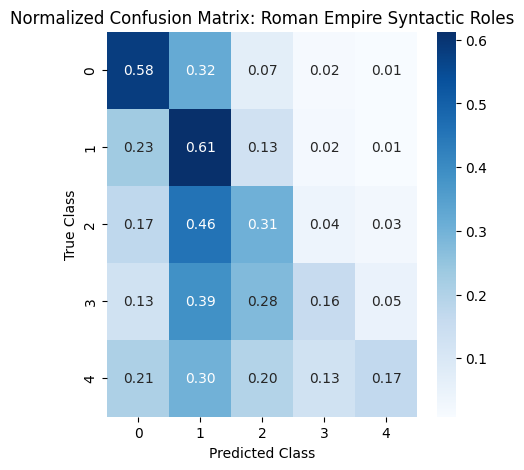

GCN results saved using amazon-mpnet-base-v2 features.
Training Time 2.8111681938171387


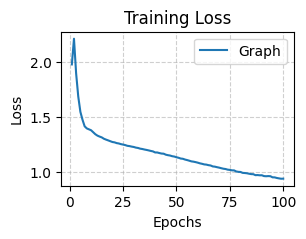

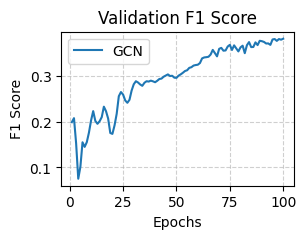

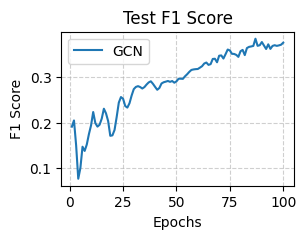

In [22]:
gcn_run()

In [25]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 200,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

In [23]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        model_name="GraphSAGE",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 1.4660, Val F1: 0.2139,Val Acc: 0.3942, Time: 0.01s
Epoch: 020, Loss: 1.3061, Val F1: 0.2373,Val Acc: 0.3728, Time: 0.01s
Epoch: 030, Loss: 1.2600, Val F1: 0.2705,Val Acc: 0.4330, Time: 0.01s
Epoch: 040, Loss: 1.2100, Val F1: 0.2907,Val Acc: 0.4406, Time: 0.01s
Epoch: 050, Loss: 1.1464, Val F1: 0.3382,Val Acc: 0.4506, Time: 0.01s
Epoch: 060, Loss: 1.0611, Val F1: 0.3708,Val Acc: 0.4498, Time: 0.01s
Epoch: 070, Loss: 0.9411, Val F1: 0.3796,Val Acc: 0.4537, Time: 0.01s
Epoch: 080, Loss: 0.8451, Val F1: 0.4212,Val Acc: 0.5063, Time: 0.01s
Epoch: 090, Loss: 0.6757, Val F1: 0.4394,Val Acc: 0.5159, Time: 0.01s
Epoch: 100, Loss: 0.5448, Val F1: 0.4509,Val Acc: 0.5267, Time: 0.01s
Epoch: 110, Loss: 0.4228, Val F1: 0.4704,Val Acc: 0.5339, Time: 0.01s
Epoch: 120, Loss: 0.3175, Val F1: 0.4717,Val Acc: 0.5400, Time: 0.01s
Epoch: 130, Loss: 0.2476, Val F1: 0.4707,Val Acc: 0.5370, Time: 0.01s
Epoch: 140, Loss: 0.1783, Val F1: 0.4723,Val Acc: 0.5349, Time: 0.01s


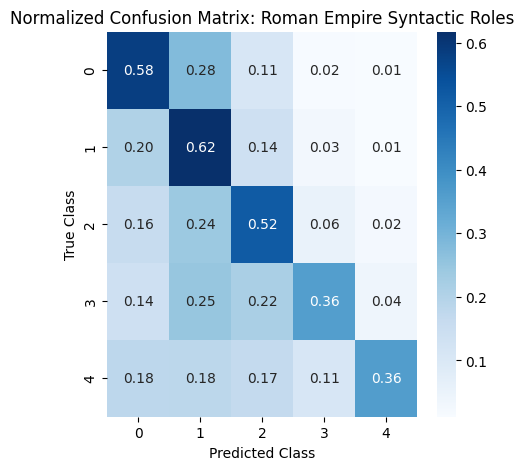

GRAPHSAGE results saved using amazon-mpnet-base-v2 features.
Training Time 1.9570319652557373


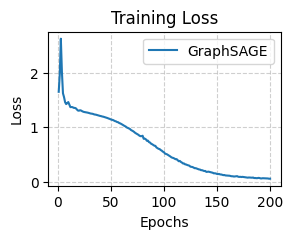

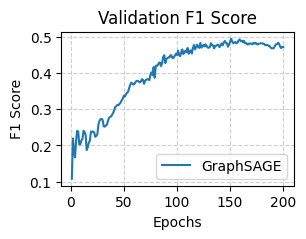

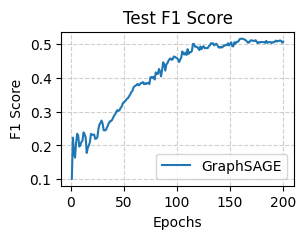

In [26]:
graphSage_run()

In [27]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GAT",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 1.4800, Val F1: 0.1066,Val Acc: 0.2487, Time: 0.03s
Epoch: 020, Loss: 1.3754, Val F1: 0.2348,Val Acc: 0.3606, Time: 0.03s
Epoch: 030, Loss: 1.3380, Val F1: 0.2237,Val Acc: 0.4067, Time: 0.03s
Epoch: 040, Loss: 1.3014, Val F1: 0.2326,Val Acc: 0.4204, Time: 0.03s
Epoch: 050, Loss: 1.2807, Val F1: 0.2696,Val Acc: 0.4402, Time: 0.03s
Epoch: 060, Loss: 1.2547, Val F1: 0.2791,Val Acc: 0.4449, Time: 0.03s
Epoch: 070, Loss: 1.2305, Val F1: 0.2900,Val Acc: 0.4516, Time: 0.03s
Epoch: 080, Loss: 1.1964, Val F1: 0.3227,Val Acc: 0.4498, Time: 0.03s
Epoch: 090, Loss: 1.1587, Val F1: 0.3283,Val Acc: 0.4522, Time: 0.03s
Epoch: 100, Loss: 1.1255, Val F1: 0.3403,Val Acc: 0.4573, Time: 0.03s
Epoch: 110, Loss: 1.0800, Val F1: 0.3559,Val Acc: 0.4630, Time: 0.03s
Epoch: 120, Loss: 1.0407, Val F1: 0.3533,Val Acc: 0.4755, Time: 0.03s
Epoch: 130, Loss: 1.0166, Val F1: 0.3619,Val Acc: 0.4608, Time: 0.03s
Epoch: 140, Loss: 0.9912, Val F1: 0.3815,Val Acc: 0.4782, Time: 0.03s
Epoch: 

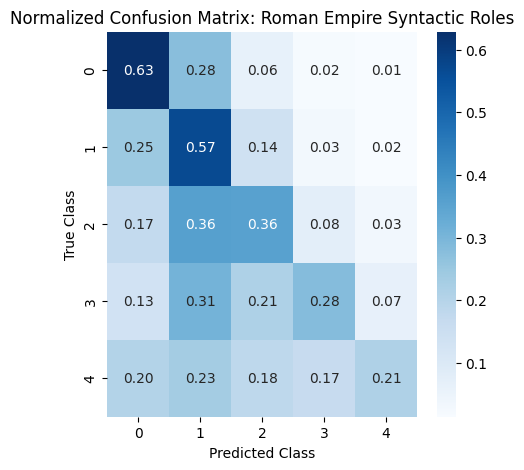

GAT results saved using amazon-mpnet-base-v2 features.
Training Time 5.758337497711182


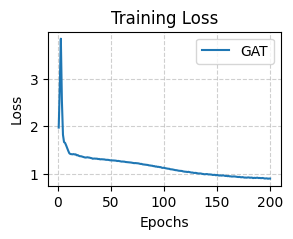

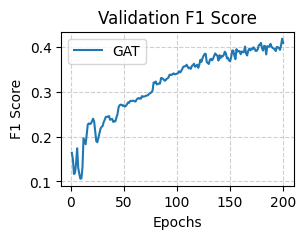

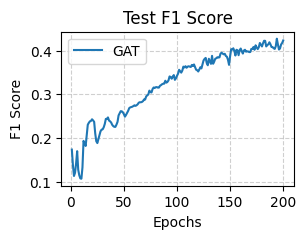

In [28]:
gat_run()

In [29]:
from GCN2 import GCN2

In [30]:
args = {
      'device': device,
      'num_layers': 10,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.001,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [31]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 010, Loss: 1.4694, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 020, Loss: 1.3640, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 030, Loss: 1.3135, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 040, Loss: 1.2708, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 050, Loss: 1.2402, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 060, Loss: 1.2155, Val F1: 0.0758,Val Acc: 0.2338, Time: 0.04s
Epoch: 070, Loss: 1.1949, Val F1: 0.0764,Val Acc: 0.2340, Time: 0.04s
Epoch: 080, Loss: 1.1804, Val F1: 0.0992,Val Acc: 0.2477, Time: 0.04s
Epoch: 090, Loss: 1.1662, Val F1: 0.1936,Val Acc: 0.3191, Time: 0.04s
Epoch: 100, Loss: 1.1500, Val F1: 0.2852,Val Acc: 0.3969, Time: 0.04s
Epoch: 110, Loss: 1.1413, Val F1: 0.3204,Val Acc: 0.4443, Time: 0.04s
Epoch: 120, Loss: 1.1314, Val F1: 0.3409,Val Acc: 0.4490, Time: 0.04s
Epoch: 130, Loss: 1.1187, Val F1: 0.3419,Val Acc: 0.4559, Time: 0.04s
Epoch: 140, Loss: 1.1112, Val F1: 0.3495,Val Acc: 0.4559, Time: 0.04s
Epoch: 

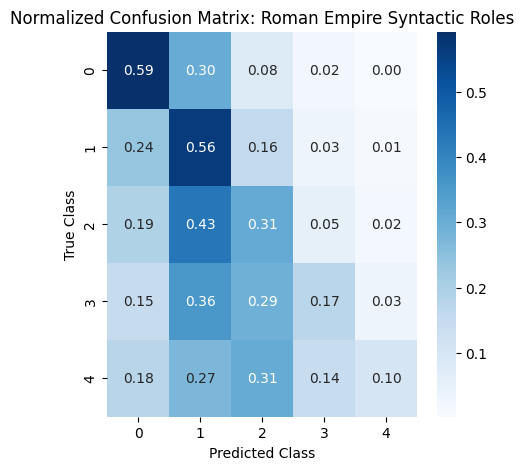

GCN2 results saved using amazon-mpnet-base-v2 features.
Training Time 17.339865684509277


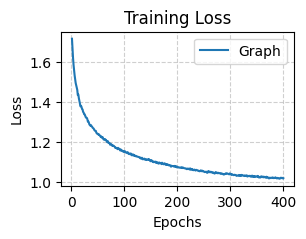

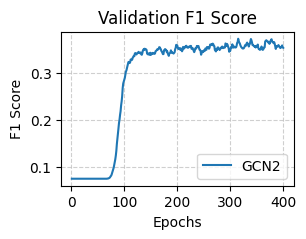

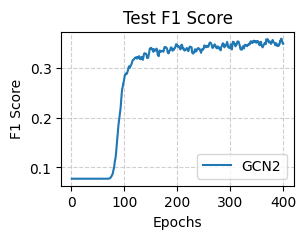

In [32]:
gcn2_run()

# H2GCN

In [33]:
from H2GCN import H2GCN

In [34]:
args = {
      'device': device,
      'num_layers': 3, #Not applicable to H2GCN
      'hidden_dim': 300,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [35]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 1.3437, Val F1: 0.1796,Val Acc: 0.3781, Time: 0.01s
Epoch: 020, Loss: 1.2322, Val F1: 0.2139,Val Acc: 0.4206, Time: 0.01s
Epoch: 030, Loss: 1.1199, Val F1: 0.2477,Val Acc: 0.4185, Time: 0.01s
Epoch: 040, Loss: 1.0531, Val F1: 0.2284,Val Acc: 0.4096, Time: 0.01s
Epoch: 050, Loss: 0.9459, Val F1: 0.3183,Val Acc: 0.4034, Time: 0.01s
Epoch: 060, Loss: 0.8836, Val F1: 0.3738,Val Acc: 0.4459, Time: 0.01s
Epoch: 070, Loss: 0.8591, Val F1: 0.4036,Val Acc: 0.4575, Time: 0.01s
Epoch: 080, Loss: 0.7966, Val F1: 0.3997,Val Acc: 0.4698, Time: 0.01s
Epoch: 090, Loss: 0.7674, Val F1: 0.4222,Val Acc: 0.4798, Time: 0.01s
Epoch: 100, Loss: 0.7130, Val F1: 0.4297,Val Acc: 0.4806, Time: 0.01s
Test F1: 0.4160
Test Accuracy: 0.4850


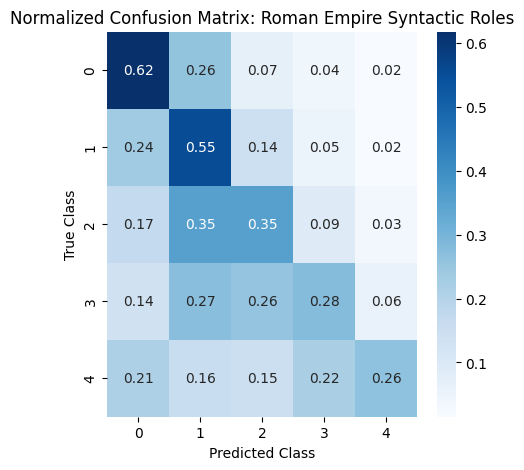

H2GCN results saved using amazon-mpnet-base-v2 features.
Training Time 1.2387664318084717


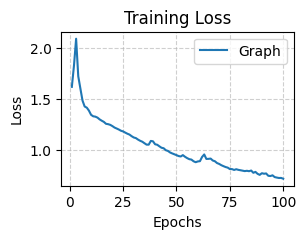

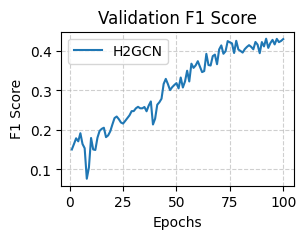

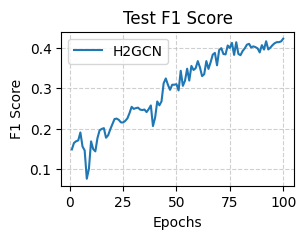

In [36]:
h2GCN_run()